# Fit an observed SED: single star or binary?
**Question:** can the combined light of a real double-lined binary be represented by two coeval stars?

Gaia DR3 **858860697467058688** is an SB2 in the Gaia DR3 NSS catalogue. We load its
observed XP spectrum and 2MASS photometry, fit a single star and a coeval binary,
and compare the SED mass ratio with the RV mass ratio. Allow **6 minutes**.

## Download the SED
`download` takes a Gaia DR3 `source_id` (or `ra=..., dec=...`). It queries the Gaia archive,
calibrates the XP continuous spectrum with GaiaXPy into 61 channels, and adds the
Gaia-linked 2MASS and AllWISE photometry, keeping native errors and quality flags.
Raw tables and the `SED` are cached: the first call takes ~30 s, later calls are instant.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '../src')
from sedkit import download, fit, plot

sed = download('858860697467058688', cache_dir='data')
print(f'parallax {sed.parallax_mas:.3f} mas, {sed.fit_mask().sum()} fitted channels (W1/W2 held out)')
!ls data/858860697467058688

parallax 10.977 mas, 64 fitted channels (W1/W2 held out)
2mass.ecsv   allwise.ecsv gaia.ecsv    sed.npz      xp.ecsv      xp.xml


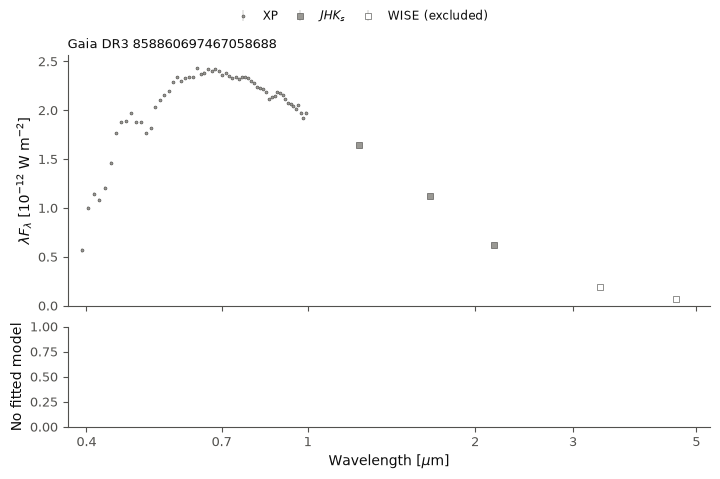

In [2]:
plot(sed);

Fluxes are absolute, at the star's distance; neither the data nor the model is normalized.

## Single star versus coeval binary
The binary is a physical sum of two PARSEC-linked coeval stars of the bundled empirical model.
Both hypotheses see the same fluxes and errors; the catalogue parallax sets the absolute scale.
A companion therefore has to supply its own light: its luminosity is the evidence.

In [3]:
%%time
result = fit(sed, age_gyr=None, feh=None, fit_parallax=True)
for kind in ('single', 'binary'):
    r = result[kind]
    print(f"{kind:6s} M1={r['m1']:.3f} q={r['q']:.3f} age={r['age_gyr']:.1f} Gyr "
          f"[M/H]={r['feh']:.2f} chi2/N={r['chi2'] / r['n_fit']:.2f}")
print(f"single - binary objective: {result['delta']:.0f}")

single M1=0.941 q=0.000 age=10.0 Gyr [M/H]=0.40 chi2/N=7.22
binary M1=0.865 q=0.840 age=10.0 Gyr [M/H]=0.07 chi2/N=1.02
single - binary objective: 399
CPU times: user 2.29 s, sys: 15.7 ms, total: 2.3 s
Wall time: 2.32 s


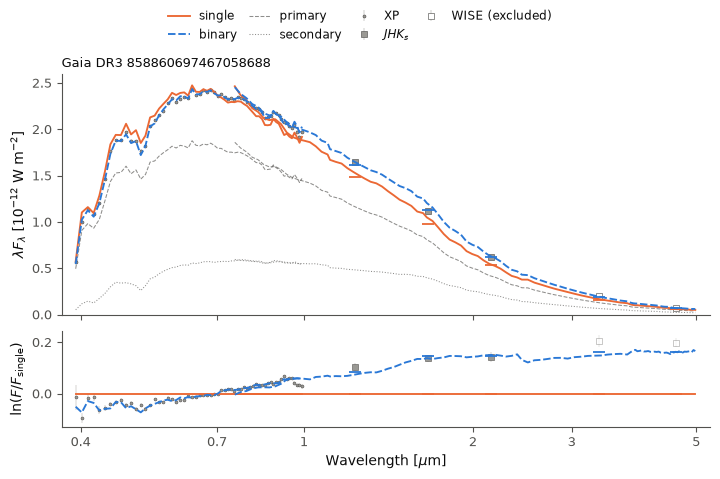

In [4]:
plot(sed, result);

## Compare with the RV mass ratio
For an SB2, $q = K_1/K_2$. The Gaia NSS amplitudes are a check, not an input to the fit.

In [5]:
k1, k2 = 49.908, 57.503  # Gaia DR3 NSS SB2 semi-amplitudes [km/s]
print(f"q_RV = {k1 / k2:.3f}, q_SED = {result['binary']['q']:.3f}")

q_RV = 0.868, q_SED = 0.840


## What this example tells us
The binary fits much better and its mass ratio is close to the RV value. `delta` is a
model-preference diagnostic, not a binary probability; the fit returns local optima
without posterior errors, and the age here reaches the 10 Gyr model boundary.
One star does not measure mass accuracy, completeness or false positives.

## Use it on your sample
```bash
pip install "sedkit[download] @ git+https://github.com/jiadonglee/sedkit.git"
```
```python
from sedkit import query_gaia, download, fit
ids = query_gaia('SELECT TOP 100 source_id FROM gaiadr3.gaia_source WHERE parallax > 10',
                 cache_dir='data/catalogue')['source_id']   # resumable asynchronous query
results = {i: fit(download(str(i), cache_dir='data'), age_gyr=5.0, feh=0.0) for i in ids}
```
Fitting both hypotheses takes about 2 s per star on one laptop core with free age and
[M/H] (timed above) and 0.4 s with them fixed. The first `download` of a star takes ~30 s
and dominates; cached stars load instantly. For catalogue-scale work, `download_gaia`
fetches raw XP/RVS/epoch products in resumable batches; it does not calibrate them into `SED`s. NumPy and SciPy only; no GPU or model download.

Supported: nearby FGKM main-sequence stars with Gaia XP, zero extinction, and a coeval
main-sequence companion. White dwarfs, triples, giants and reddened stars are outside the model.

**Discussion:** what would be lost if both the data and the model were normalized?

Next: [is a Gaia brown-dwarf orbit a hidden twin?](02_gaia_orbit_twin.ipynb)